In [4097]:
print("AtmoSync Python is working!")

AtmoSync Python is working!


In [4098]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

Load Dataset

In [4099]:
import pandas as pd

df = pd.read_csv("D:\Projects\AtmoSync\Data\AtmoSync_Micro_Climate_Analytics_12000.csv")

df.head()

,Record_ID,Date,Time,City,Latitude,Longitude,Temperature_C,Feels_Like_C,Humidity_Percent,Dew_Point_C,...,NO2_ugm3,CO_mg_m3,O3_ugm3,AQI,Population_Millions,Energy_Demand_MW,Energy_Price_INR_kWh,Heat_Index_C,Pollution_Level,Climate_Opportunity_Score
0,1,2025-01-01,00:00,Chennai,13.0827,80.2707,25.28,26.93,81.7,21.63,...,43.99,0.452,26.04,43.7,11.0,409.0,7.25,26.93,Good,47.7
1,2,2025-01-01,01:00,Ahmedabad,23.0225,72.5714,25.98,27.61,89.6,23.91,...,47.12,0.787,25.83,60.9,8.0,333.2,6.69,27.61,Moderate,35.6
2,3,2025-01-01,02:00,Delhi,28.6139,77.2090,20.18,20.56,70.9,14.37,...,30.88,0.532,27.26,60.9,33.0,1272.5,11.32,20.56,Moderate,44.7
3,4,2025-01-01,03:00,Mumbai,19.0760,72.8777,19.95,21.50,88.9,17.74,...,46.07,0.774,36.93,54.4,21.0,778.4,8.68,21.50,Moderate,39.0
4,5,2025-01-01,04:00,Mumbai,19.0760,72.8777,20.91,23.27,89.3,18.78,...,34.95,0.900,27.26,52.0,21.0,793.9,9.11,23.27,Moderate,50.2


Dataset overview

In [4100]:
df.shape

(12000, 27)

In [4101]:
df.columns

Index(['Record_ID', 'Date', 'Time', 'City', 'Latitude', 'Longitude',
       'Temperature_C', 'Feels_Like_C', 'Humidity_Percent', 'Dew_Point_C',
       'Pressure_hPa', 'Rainfall_mm', 'Wind_Speed_kmh', 'Cloud_Cover_Percent',
       'Solar_Radiation_Wm2', 'PM2_5_ugm3', 'PM10_ugm3', 'NO2_ugm3',
       'CO_mg_m3', 'O3_ugm3', 'AQI', 'Population_Millions', 'Energy_Demand_MW',
       'Energy_Price_INR_kWh', 'Heat_Index_C', 'Pollution_Level',
       'Climate_Opportunity_Score'],
      dtype='object')

In [4102]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 12000 entries, 0 to 11999
Data columns (total 27 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   Record_ID                  12000 non-null  int64  
 1   Date                       12000 non-null  object 
 2   Time                       12000 non-null  object 
 3   City                       12000 non-null  object 
 4   Latitude                   12000 non-null  float64
 5   Longitude                  12000 non-null  float64
 6   Temperature_C              12000 non-null  float64
 7   Feels_Like_C               12000 non-null  float64
 8   Humidity_Percent           12000 non-null  float64
 9   Dew_Point_C                12000 non-null  float64
 10  Pressure_hPa               12000 non-null  float64
 11  Rainfall_mm                12000 non-null  float64
 12  Wind_Speed_kmh             12000 non-null  float64
 13  Cloud_Cover_Percent        12000 non-null  flo

In [4103]:
df.describe()

,Record_ID,Latitude,Longitude,Temperature_C,Feels_Like_C,Humidity_Percent,Dew_Point_C,Pressure_hPa,Rainfall_mm,Wind_Speed_kmh,...,PM10_ugm3,NO2_ugm3,CO_mg_m3,O3_ugm3,AQI,Population_Millions,Energy_Demand_MW,Energy_Price_INR_kWh,Heat_Index_C,Climate_Opportunity_Score
count,12000.00000,12000.000000,12000.000000,12000.000000,12000.000000,12000.000000,12000.000000,12000.000000,12000.000000,12000.000000,...,12000.000000,12000.000000,12000.000000,12000.000000,12000.000000,12000.000000,12000.000000,12000.000000,12000.000000,12000.000000
mean,6000.50000,18.030932,76.156577,26.313017,27.192304,74.380408,21.189018,1010.868417,0.175657,12.989500,...,79.367479,35.585993,0.635010,33.159897,49.781317,11.303408,465.034200,7.865067,27.192304,51.874808
std,3464.24595,6.153280,2.349622,4.668504,4.340998,9.047439,3.866072,4.160927,0.920149,5.629904,...,32.326480,11.693587,0.149929,12.388744,18.180356,8.978345,362.700084,1.660396,4.340998,7.613107
min,1.00000,9.931200,72.571400,12.690000,13.340000,42.500000,8.940000,994.700000,0.000000,0.500000,...,10.000000,3.000000,0.159000,5.000000,6.500000,2.200000,35.000000,4.810000,13.340000,22.100000
25%,3000.75000,12.971600,73.856700,22.960000,24.110000,68.200000,18.460000,1008.000000,0.000000,9.090000,...,55.990000,27.317500,0.530000,23.877500,36.700000,4.000000,176.775000,6.687500,24.110000,46.500000
50%,6000.50000,18.520400,76.267300,26.340000,27.250000,74.400000,21.220000,1010.800000,0.000000,12.980000,...,75.800000,34.800000,0.628000,31.220000,47.600000,8.000000,381.950000,7.500000,27.250000,51.300000
75%,9000.25000,23.022500,77.594600,29.580000,30.200000,80.600000,23.900000,1013.700000,0.000000,16.810000,...,99.842500,43.242500,0.735000,40.932500,61.000000,13.500000,550.325000,8.380000,30.200000,56.900000
max,12000.00000,28.613900,80.270700,41.070000,40.260000,98.000000,32.980000,1030.000000,14.900000,37.220000,...,191.050000,80.810000,1.182000,81.850000,108.500000,33.000000,1637.800000,13.220000,40.260000,80.700000


In [4104]:
df.isnull().sum()

Record_ID                    0
Date                         0
Time                         0
City                         0
Latitude                     0
Longitude                    0
Temperature_C                0
Feels_Like_C                 0
Humidity_Percent             0
Dew_Point_C                  0
Pressure_hPa                 0
Rainfall_mm                  0
Wind_Speed_kmh               0
Cloud_Cover_Percent          0
Solar_Radiation_Wm2          0
PM2_5_ugm3                   0
PM10_ugm3                    0
NO2_ugm3                     0
CO_mg_m3                     0
O3_ugm3                      0
AQI                          0
Population_Millions          0
Energy_Demand_MW             0
Energy_Price_INR_kWh         0
Heat_Index_C                 0
Pollution_Level              0
Climate_Opportunity_Score    0
dtype: int64

In [4105]:
df["City"].value_counts()

City
Coimbatore    1245
Pune          1241
Mumbai        1228
Bengaluru     1220
Ahmedabad     1211
Delhi         1182
Hyderabad     1174
Jaipur        1171
Chennai       1166
Kochi         1162
Name: count, dtype: int64

In [4106]:
df.columns.tolist()

['Record_ID',
 'Date',
 'Time',
 'City',
 'Latitude',
 'Longitude',
 'Temperature_C',
 'Feels_Like_C',
 'Humidity_Percent',
 'Dew_Point_C',
 'Pressure_hPa',
 'Rainfall_mm',
 'Wind_Speed_kmh',
 'Cloud_Cover_Percent',
 'Solar_Radiation_Wm2',
 'PM2_5_ugm3',
 'PM10_ugm3',
 'NO2_ugm3',
 'CO_mg_m3',
 'O3_ugm3',
 'AQI',
 'Population_Millions',
 'Energy_Demand_MW',
 'Energy_Price_INR_kWh',
 'Heat_Index_C',
 'Pollution_Level',
 'Climate_Opportunity_Score']

In [4107]:
df.dtypes

Record_ID                      int64
Date                          object
Time                          object
City                          object
Latitude                     float64
Longitude                    float64
Temperature_C                float64
Feels_Like_C                 float64
Humidity_Percent             float64
Dew_Point_C                  float64
Pressure_hPa                 float64
Rainfall_mm                  float64
Wind_Speed_kmh               float64
Cloud_Cover_Percent          float64
Solar_Radiation_Wm2          float64
PM2_5_ugm3                   float64
PM10_ugm3                    float64
NO2_ugm3                     float64
CO_mg_m3                     float64
O3_ugm3                      float64
AQI                          float64
Population_Millions          float64
Energy_Demand_MW             float64
Energy_Price_INR_kWh         float64
Heat_Index_C                 float64
Pollution_Level               object
Climate_Opportunity_Score    float64
d

In [4108]:
df.head()

,Record_ID,Date,Time,City,Latitude,Longitude,Temperature_C,Feels_Like_C,Humidity_Percent,Dew_Point_C,...,NO2_ugm3,CO_mg_m3,O3_ugm3,AQI,Population_Millions,Energy_Demand_MW,Energy_Price_INR_kWh,Heat_Index_C,Pollution_Level,Climate_Opportunity_Score
0,1,2025-01-01,00:00,Chennai,13.0827,80.2707,25.28,26.93,81.7,21.63,...,43.99,0.452,26.04,43.7,11.0,409.0,7.25,26.93,Good,47.7
1,2,2025-01-01,01:00,Ahmedabad,23.0225,72.5714,25.98,27.61,89.6,23.91,...,47.12,0.787,25.83,60.9,8.0,333.2,6.69,27.61,Moderate,35.6
2,3,2025-01-01,02:00,Delhi,28.6139,77.2090,20.18,20.56,70.9,14.37,...,30.88,0.532,27.26,60.9,33.0,1272.5,11.32,20.56,Moderate,44.7
3,4,2025-01-01,03:00,Mumbai,19.0760,72.8777,19.95,21.50,88.9,17.74,...,46.07,0.774,36.93,54.4,21.0,778.4,8.68,21.50,Moderate,39.0
4,5,2025-01-01,04:00,Mumbai,19.0760,72.8777,20.91,23.27,89.3,18.78,...,34.95,0.900,27.26,52.0,21.0,793.9,9.11,23.27,Moderate,50.2


In [4109]:
df.tail()

,Record_ID,Date,Time,City,Latitude,Longitude,Temperature_C,Feels_Like_C,Humidity_Percent,Dew_Point_C,...,NO2_ugm3,CO_mg_m3,O3_ugm3,AQI,Population_Millions,Energy_Demand_MW,Energy_Price_INR_kWh,Heat_Index_C,Pollution_Level,Climate_Opportunity_Score
11995,11996,2026-05-15,19:00,Kochi,9.9312,76.2673,32.87,34.07,62.6,25.39,...,43.52,0.804,26.79,52.9,2.2,153.0,6.88,34.07,Moderate,60.3
11996,11997,2026-05-15,20:00,Chennai,13.0827,80.2707,35.71,35.49,55.5,26.82,...,38.97,0.656,33.20,46.2,11.0,491.6,8.37,35.49,Good,48.8
11997,11998,2026-05-15,21:00,Kochi,9.9312,76.2673,35.17,34.15,58.3,26.84,...,30.54,0.616,33.64,34.6,2.2,161.7,6.79,34.15,Good,54.4
11998,11999,2026-05-15,22:00,Hyderabad,17.3850,78.4867,31.41,31.61,60.8,23.57,...,43.08,0.687,23.61,49.0,10.5,429.2,8.11,31.61,Good,53.1
11999,12000,2026-05-15,23:00,Kochi,9.9312,76.2673,34.78,34.91,71.9,29.16,...,33.62,0.560,35.21,40.5,2.2,126.4,6.50,34.91,Good,57.2


In [4110]:
df.isnull().sum().sum()

np.int64(0)

In [4111]:
(df.isnull().sum() / len(df) * 100).sort_values(ascending=False)

Record_ID                    0.0
Solar_Radiation_Wm2          0.0
Pollution_Level              0.0
Heat_Index_C                 0.0
Energy_Price_INR_kWh         0.0
Energy_Demand_MW             0.0
Population_Millions          0.0
AQI                          0.0
O3_ugm3                      0.0
CO_mg_m3                     0.0
NO2_ugm3                     0.0
PM10_ugm3                    0.0
PM2_5_ugm3                   0.0
Cloud_Cover_Percent          0.0
Date                         0.0
Wind_Speed_kmh               0.0
Rainfall_mm                  0.0
Pressure_hPa                 0.0
Dew_Point_C                  0.0
Humidity_Percent             0.0
Feels_Like_C                 0.0
Temperature_C                0.0
Longitude                    0.0
Latitude                     0.0
City                         0.0
Time                         0.0
Climate_Opportunity_Score    0.0
dtype: float64

In [4112]:
df.duplicated().sum()

np.int64(0)

In [4113]:
df["Record_ID"].nunique()

12000

In [4114]:
df["Date"] = pd.to_datetime(df["Date"])

In [4115]:
df["Date"].dtype

dtype('<M8[ns]')

In [4116]:
df.head()

,Record_ID,Date,Time,City,Latitude,Longitude,Temperature_C,Feels_Like_C,Humidity_Percent,Dew_Point_C,...,NO2_ugm3,CO_mg_m3,O3_ugm3,AQI,Population_Millions,Energy_Demand_MW,Energy_Price_INR_kWh,Heat_Index_C,Pollution_Level,Climate_Opportunity_Score
0,1,2025-01-01,00:00,Chennai,13.0827,80.2707,25.28,26.93,81.7,21.63,...,43.99,0.452,26.04,43.7,11.0,409.0,7.25,26.93,Good,47.7
1,2,2025-01-01,01:00,Ahmedabad,23.0225,72.5714,25.98,27.61,89.6,23.91,...,47.12,0.787,25.83,60.9,8.0,333.2,6.69,27.61,Moderate,35.6
2,3,2025-01-01,02:00,Delhi,28.6139,77.2090,20.18,20.56,70.9,14.37,...,30.88,0.532,27.26,60.9,33.0,1272.5,11.32,20.56,Moderate,44.7
3,4,2025-01-01,03:00,Mumbai,19.0760,72.8777,19.95,21.50,88.9,17.74,...,46.07,0.774,36.93,54.4,21.0,778.4,8.68,21.50,Moderate,39.0
4,5,2025-01-01,04:00,Mumbai,19.0760,72.8777,20.91,23.27,89.3,18.78,...,34.95,0.900,27.26,52.0,21.0,793.9,9.11,23.27,Moderate,50.2


In [4117]:
df["Year"] = df["Date"].dt.year
df["Month"] = df["Date"].dt.month
df["Month_Name"] = df["Date"].dt.month_name()
df["Day"] = df["Date"].dt.day
df["Day_of_Week"] = df["Date"].dt.day_name()

In [4118]:
df.head()

,Record_ID,Date,Time,City,Latitude,Longitude,Temperature_C,Feels_Like_C,Humidity_Percent,Dew_Point_C,...,Energy_Demand_MW,Energy_Price_INR_kWh,Heat_Index_C,Pollution_Level,Climate_Opportunity_Score,Year,Month,Month_Name,Day,Day_of_Week
0,1,2025-01-01,00:00,Chennai,13.0827,80.2707,25.28,26.93,81.7,21.63,...,409.0,7.25,26.93,Good,47.7,2025,1,January,1,Wednesday
1,2,2025-01-01,01:00,Ahmedabad,23.0225,72.5714,25.98,27.61,89.6,23.91,...,333.2,6.69,27.61,Moderate,35.6,2025,1,January,1,Wednesday
2,3,2025-01-01,02:00,Delhi,28.6139,77.2090,20.18,20.56,70.9,14.37,...,1272.5,11.32,20.56,Moderate,44.7,2025,1,January,1,Wednesday
3,4,2025-01-01,03:00,Mumbai,19.0760,72.8777,19.95,21.50,88.9,17.74,...,778.4,8.68,21.50,Moderate,39.0,2025,1,January,1,Wednesday
4,5,2025-01-01,04:00,Mumbai,19.0760,72.8777,20.91,23.27,89.3,18.78,...,793.9,9.11,23.27,Moderate,50.2,2025,1,January,1,Wednesday


In [4119]:
df["Hour"] = pd.to_datetime(
    df["Time"],
    format="%H:%M"
).dt.hour

In [4120]:
df.head()

,Record_ID,Date,Time,City,Latitude,Longitude,Temperature_C,Feels_Like_C,Humidity_Percent,Dew_Point_C,...,Energy_Price_INR_kWh,Heat_Index_C,Pollution_Level,Climate_Opportunity_Score,Year,Month,Month_Name,Day,Day_of_Week,Hour
0,1,2025-01-01,00:00,Chennai,13.0827,80.2707,25.28,26.93,81.7,21.63,...,7.25,26.93,Good,47.7,2025,1,January,1,Wednesday,0
1,2,2025-01-01,01:00,Ahmedabad,23.0225,72.5714,25.98,27.61,89.6,23.91,...,6.69,27.61,Moderate,35.6,2025,1,January,1,Wednesday,1
2,3,2025-01-01,02:00,Delhi,28.6139,77.2090,20.18,20.56,70.9,14.37,...,11.32,20.56,Moderate,44.7,2025,1,January,1,Wednesday,2
3,4,2025-01-01,03:00,Mumbai,19.0760,72.8777,19.95,21.50,88.9,17.74,...,8.68,21.50,Moderate,39.0,2025,1,January,1,Wednesday,3
4,5,2025-01-01,04:00,Mumbai,19.0760,72.8777,20.91,23.27,89.3,18.78,...,9.11,23.27,Moderate,50.2,2025,1,January,1,Wednesday,4


In [4121]:
df.describe()

,Record_ID,Date,Latitude,Longitude,Temperature_C,Feels_Like_C,Humidity_Percent,Dew_Point_C,Pressure_hPa,Rainfall_mm,...,AQI,Population_Millions,Energy_Demand_MW,Energy_Price_INR_kWh,Heat_Index_C,Climate_Opportunity_Score,Year,Month,Day,Hour
count,12000.00000,12000,12000.000000,12000.000000,12000.000000,12000.000000,12000.000000,12000.000000,12000.000000,12000.000000,...,12000.000000,12000.000000,12000.000000,12000.000000,12000.000000,12000.000000,12000.000000,12000.000000,12000.000000,12000.000000
mean,6000.50000,2025-09-07 12:00:00,18.030932,76.156577,26.313017,27.192304,74.380408,21.189018,1010.868417,0.175657,...,49.781317,11.303408,465.034200,7.865067,27.192304,51.874808,2025.270000,5.514000,15.442000,11.500000
min,1.00000,2025-01-01 00:00:00,9.931200,72.571400,12.690000,13.340000,42.500000,8.940000,994.700000,0.000000,...,6.500000,2.200000,35.000000,4.810000,13.340000,22.100000,2025.000000,1.000000,1.000000,0.000000
25%,3000.75000,2025-05-05 18:00:00,12.971600,73.856700,22.960000,24.110000,68.200000,18.460000,1008.000000,0.000000,...,36.700000,4.000000,176.775000,6.687500,24.110000,46.500000,2025.000000,3.000000,8.000000,5.750000
50%,6000.50000,2025-09-07 12:00:00,18.520400,76.267300,26.340000,27.250000,74.400000,21.220000,1010.800000,0.000000,...,47.600000,8.000000,381.950000,7.500000,27.250000,51.300000,2025.000000,5.000000,15.000000,11.500000
75%,9000.25000,2026-01-10 06:00:00,23.022500,77.594600,29.580000,30.200000,80.600000,23.900000,1013.700000,0.000000,...,61.000000,13.500000,550.325000,8.380000,30.200000,56.900000,2026.000000,8.000000,23.000000,17.250000
max,12000.00000,2026-05-15 00:00:00,28.613900,80.270700,41.070000,40.260000,98.000000,32.980000,1030.000000,14.900000,...,108.500000,33.000000,1637.800000,13.220000,40.260000,80.700000,2026.000000,12.000000,31.000000,23.000000
std,3464.24595,NaN,6.153280,2.349622,4.668504,4.340998,9.047439,3.866072,4.160927,0.920149,...,18.180356,8.978345,362.700084,1.660396,4.340998,7.613107,0.443978,3.452361,8.770692,6.922475


In [4122]:
df.groupby("City")[
    [
        "Temperature_C",
        "Humidity_Percent",
        "AQI",
        "Energy_Demand_MW",
        "Energy_Price_INR_kWh",
        "Climate_Opportunity_Score"
    ]
].mean().round(2)

,Temperature_C,Humidity_Percent,AQI,Energy_Demand_MW,Energy_Price_INR_kWh,Climate_Opportunity_Score
City,,,,,,
Ahmedabad,27.71,74.80,58.06,336.01,7.30,51.95
Bengaluru,23.84,74.15,37.16,546.17,8.23,51.58
Chennai,28.24,74.49,46.27,463.34,7.87,53.35
Coimbatore,26.01,74.02,33.03,106.37,6.27,53.00
Delhi,24.68,74.71,82.22,1330.00,11.75,48.57
Hyderabad,27.10,73.91,51.59,433.80,7.70,51.96
Jaipur,25.80,74.34,69.96,169.20,6.54,49.84
Kochi,27.83,74.29,29.60,105.56,6.24,54.17
Mumbai,27.17,74.68,48.93,856.53,9.62,52.08


In [4123]:
df["City"].value_counts()

City
Coimbatore    1245
Pune          1241
Mumbai        1228
Bengaluru     1220
Ahmedabad     1211
Delhi         1182
Hyderabad     1174
Jaipur        1171
Chennai       1166
Kochi         1162
Name: count, dtype: int64

In [4124]:
clean_df = df.copy()

In [4125]:
clean_df.isnull().sum()

Record_ID                    0
Date                         0
Time                         0
City                         0
Latitude                     0
Longitude                    0
Temperature_C                0
Feels_Like_C                 0
Humidity_Percent             0
Dew_Point_C                  0
Pressure_hPa                 0
Rainfall_mm                  0
Wind_Speed_kmh               0
Cloud_Cover_Percent          0
Solar_Radiation_Wm2          0
PM2_5_ugm3                   0
PM10_ugm3                    0
NO2_ugm3                     0
CO_mg_m3                     0
O3_ugm3                      0
AQI                          0
Population_Millions          0
Energy_Demand_MW             0
Energy_Price_INR_kWh         0
Heat_Index_C                 0
Pollution_Level              0
Climate_Opportunity_Score    0
Year                         0
Month                        0
Month_Name                   0
Day                          0
Day_of_Week                  0
Hour    

In [4126]:
clean_df.duplicated().sum()

np.int64(0)

In [4127]:
clean_df["Humidity_Percent"].describe()

count    12000.000000
mean        74.380408
std          9.047439
min         42.500000
25%         68.200000
50%         74.400000
75%         80.600000
max         98.000000
Name: Humidity_Percent, dtype: float64

In [4128]:
clean_df[
    (clean_df["Humidity_Percent"] < 0) |
    (clean_df["Humidity_Percent"] > 100)
]

,Record_ID,Date,Time,City,Latitude,Longitude,Temperature_C,Feels_Like_C,Humidity_Percent,Dew_Point_C,...,Energy_Price_INR_kWh,Heat_Index_C,Pollution_Level,Climate_Opportunity_Score,Year,Month,Month_Name,Day,Day_of_Week,Hour


In [4129]:
clean_df["AQI"].describe()

count    12000.000000
mean        49.781317
std         18.180356
min          6.500000
25%         36.700000
50%         47.600000
75%         61.000000
max        108.500000
Name: AQI, dtype: float64

In [4130]:
clean_df["Temperature_C"].describe()

count    12000.000000
mean        26.313017
std          4.668504
min         12.690000
25%         22.960000
50%         26.340000
75%         29.580000
max         41.070000
Name: Temperature_C, dtype: float64

In [4131]:
clean_df["Energy_Demand_MW"].describe()

count    12000.000000
mean       465.034200
std        362.700084
min         35.000000
25%        176.775000
50%        381.950000
75%        550.325000
max       1637.800000
Name: Energy_Demand_MW, dtype: float64

In [4132]:
city_counts = (
    clean_df["City"]
    .value_counts()
    .reset_index()
)

city_counts.columns = ["City", "Records"]

city_counts

,City,Records
0,Coimbatore,1245
1,Pune,1241
2,Mumbai,1228
3,Bengaluru,1220
4,Ahmedabad,1211
5,Delhi,1182
6,Hyderabad,1174
7,Jaipur,1171
8,Chennai,1166
9,Kochi,1162


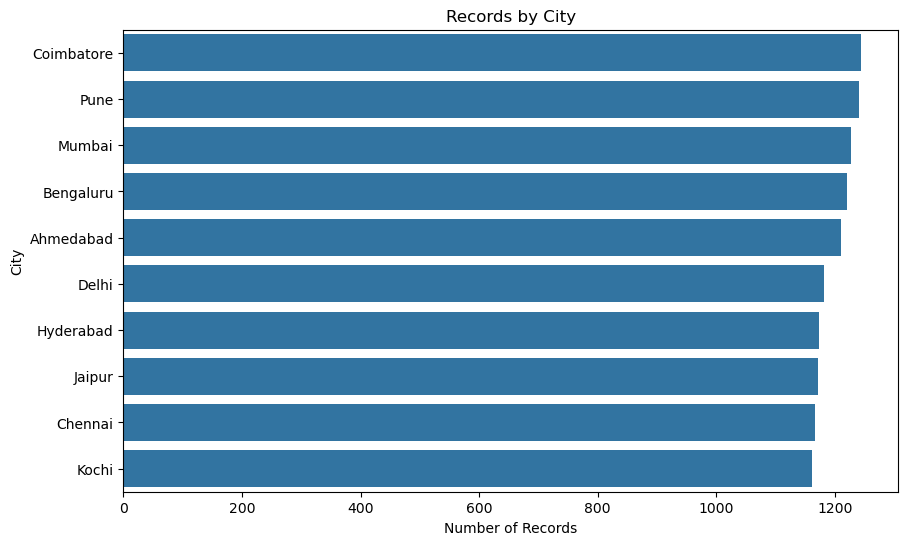

In [4133]:
plt.figure(figsize=(10, 6))

sns.barplot(
    data=city_counts,
    x="Records",
    y="City"
)

plt.title("Records by City")
plt.xlabel("Number of Records")
plt.ylabel("City")

plt.show()

In [4134]:
temperature_city = (
    clean_df
    .groupby("City")["Temperature_C"]
    .mean()
    .sort_values(ascending=False)
)

temperature_city

City
Chennai       28.244280
Kochi         27.831721
Ahmedabad     27.706226
Mumbai        27.170366
Hyderabad     27.101048
Coimbatore    26.012602
Jaipur        25.803194
Pune          24.891644
Delhi         24.680000
Bengaluru     23.840418
Name: Temperature_C, dtype: float64

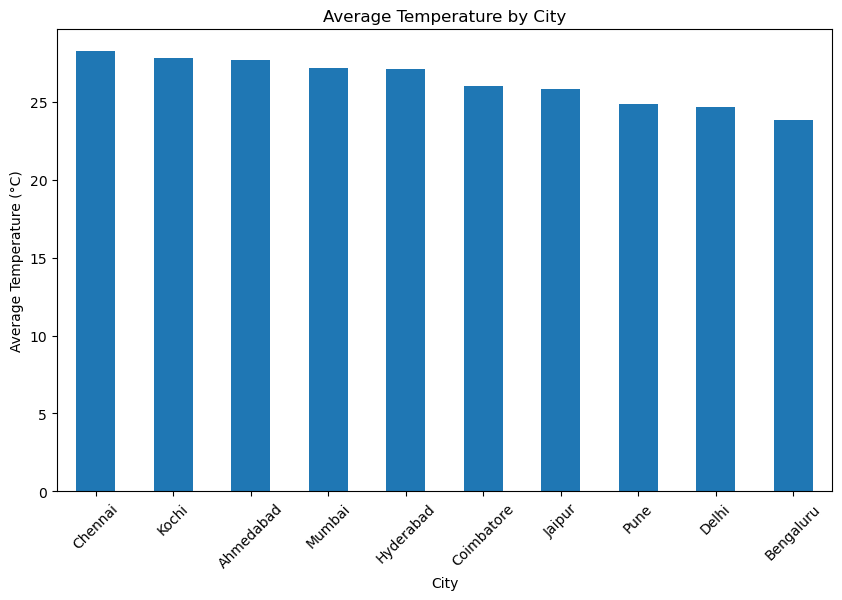

In [4135]:
temperature_city.plot(
    kind="bar",
    figsize=(10,6)
)

plt.title("Average Temperature by City")
plt.xlabel("City")
plt.ylabel("Average Temperature (°C)")
plt.xticks(rotation=45)

plt.show()

In [4136]:
humidity_city = (
    clean_df
    .groupby("City")["Humidity_Percent"]
    .mean()
    .sort_values(ascending=False)
)

humidity_city

City
Ahmedabad     74.798431
Delhi         74.708799
Mumbai        74.676629
Chennai       74.494511
Pune          74.412329
Jaipur        74.339539
Kochi         74.294923
Bengaluru     74.151311
Coimbatore    74.016627
Hyderabad     73.910903
Name: Humidity_Percent, dtype: float64

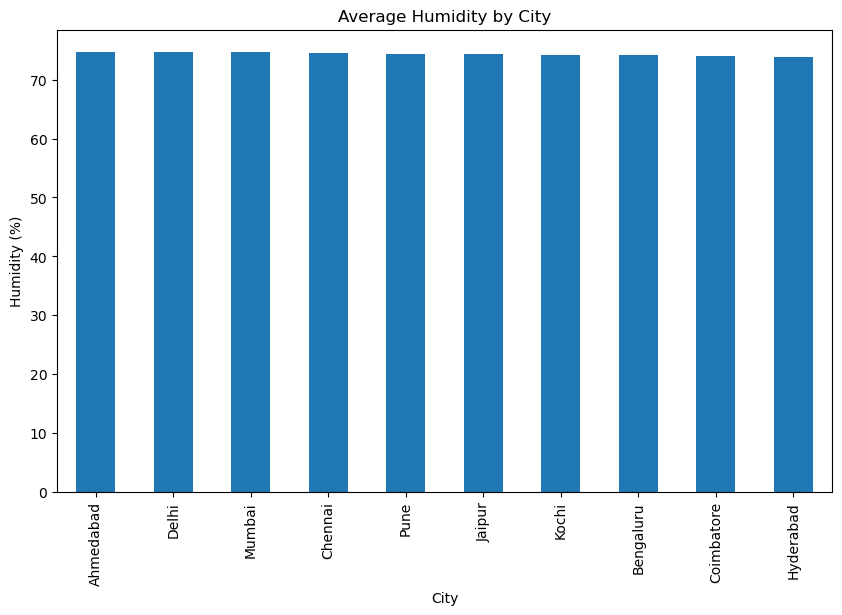

In [4137]:
humidity_city.plot(
    kind="bar",
    figsize=(10,6)
)

plt.title("Average Humidity by City")
plt.ylabel("Humidity (%)")
plt.xlabel("City")

plt.show()

In [4138]:
aqi_city = (
    clean_df
    .groupby("City")["AQI"]
    .mean()
    .sort_values(ascending=False)
)

aqi_city

City
Delhi         82.219882
Jaipur        69.964219
Ahmedabad     58.060363
Hyderabad     51.594719
Mumbai        48.925407
Chennai       46.270669
Pune          42.296052
Bengaluru     37.161230
Coimbatore    33.033574
Kochi         29.600344
Name: AQI, dtype: float64

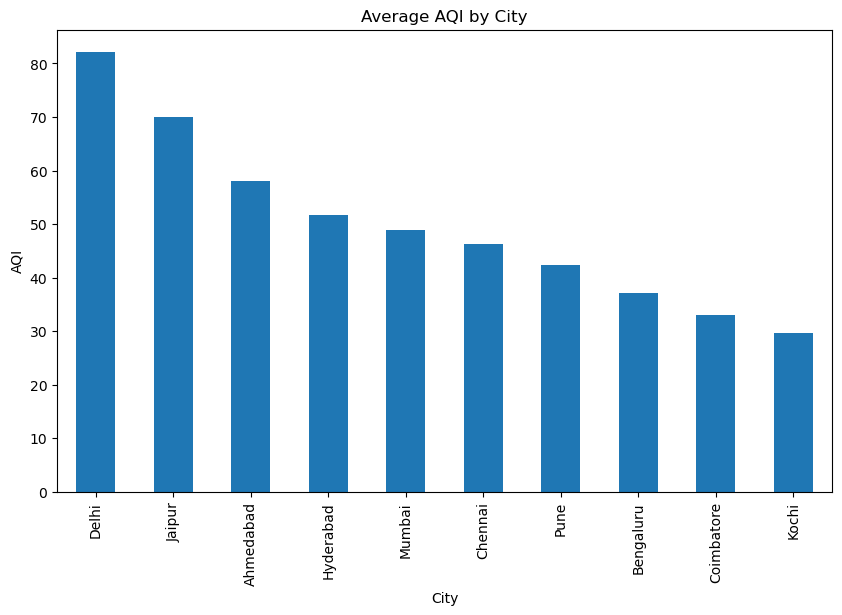

In [4139]:
aqi_city.plot(
    kind="bar",
    figsize=(10,6)
)

plt.title("Average AQI by City")
plt.ylabel("AQI")
plt.xlabel("City")

plt.show()

In [4140]:
energy_demand_city = (
    clean_df
    .groupby("City")["Energy_Demand_MW"]
    .mean()
    .sort_values(ascending=False)
)

energy_demand_city

City
Delhi         1330.002707
Mumbai         856.527117
Bengaluru      546.171066
Chennai        463.335935
Hyderabad      433.796763
Ahmedabad      336.010405
Pune           306.641096
Jaipur         169.200939
Coimbatore     106.372771
Kochi          105.557229
Name: Energy_Demand_MW, dtype: float64

In [4141]:
energy_price_city = (
    clean_df
    .groupby("City")["Energy_Price_INR_kWh"]
    .mean()
    .sort_values(ascending=False)
)

energy_price_city

City
Delhi         11.746633
Mumbai         9.624332
Bengaluru      8.226000
Chennai        7.867084
Hyderabad      7.698612
Ahmedabad      7.302353
Pune           7.156825
Jaipur         6.537950
Coimbatore     6.265365
Kochi          6.238907
Name: Energy_Price_INR_kWh, dtype: float64

In [4142]:
opportunity_city = (
    clean_df
    .groupby("City")["Climate_Opportunity_Score"]
    .mean()
    .sort_values(ascending=False)
)

opportunity_city

City
Kochi         54.166179
Chennai       53.349828
Coimbatore    52.999116
Pune          52.211845
Mumbai        52.078257
Hyderabad     51.955281
Ahmedabad     51.953014
Bengaluru     51.581311
Jaipur        49.844492
Delhi         48.571997
Name: Climate_Opportunity_Score, dtype: float64

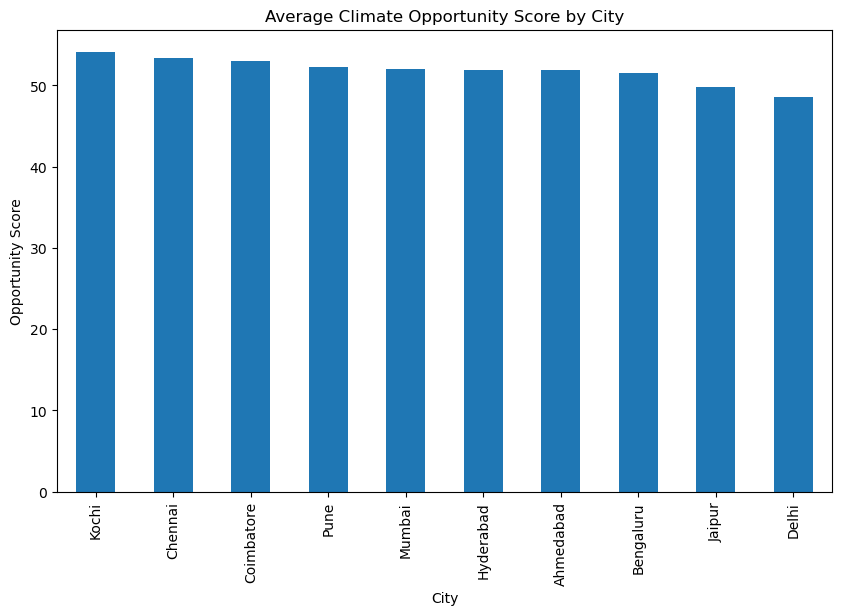

In [4143]:
opportunity_city.plot(
    kind="bar",
    figsize=(10,6)
)

plt.title("Average Climate Opportunity Score by City")
plt.ylabel("Opportunity Score")
plt.xlabel("City")

plt.show()

Temperature vs Energy Demand

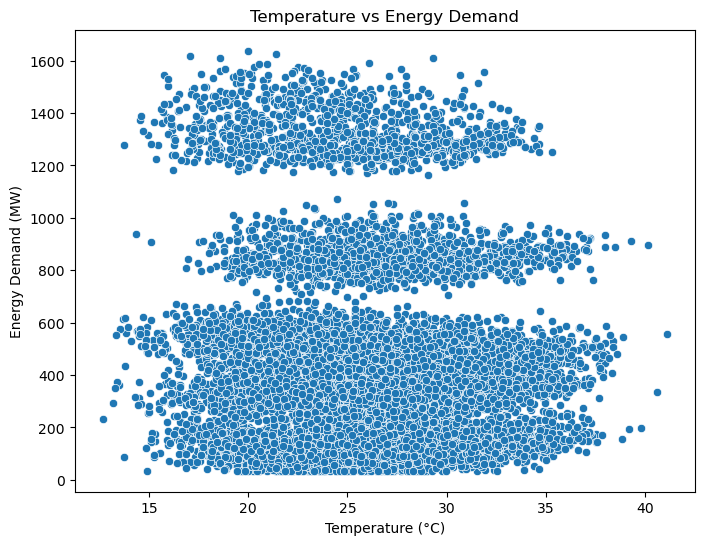

In [4144]:
plt.figure(figsize=(8,6))

sns.scatterplot(
    data=clean_df,
    x="Temperature_C",
    y="Energy_Demand_MW"
)

plt.title("Temperature vs Energy Demand")
plt.xlabel("Temperature (°C)")
plt.ylabel("Energy Demand (MW)")

plt.show()

In [4145]:
clean_df[
    ["Temperature_C", "Energy_Demand_MW"]
].corr()

,Temperature_C,Energy_Demand_MW
Temperature_C,1.000000,-0.078077
Energy_Demand_MW,-0.078077,1.000000


Humidity vs Energy Demand

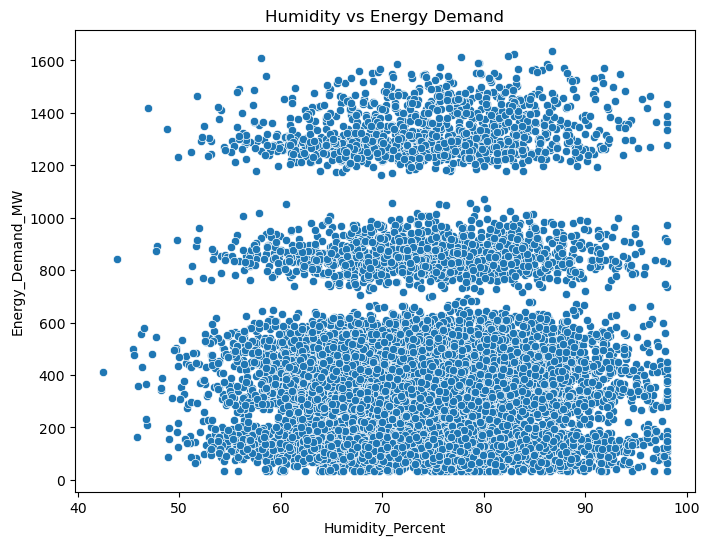

In [4146]:
plt.figure(figsize=(8,6))

sns.scatterplot(
    data=clean_df,
    x="Humidity_Percent",
    y="Energy_Demand_MW"
)

plt.title("Humidity vs Energy Demand")

plt.show()

In [4147]:
clean_df[
    ["Humidity_Percent", "Energy_Demand_MW"]
].corr()

,Humidity_Percent,Energy_Demand_MW
Humidity_Percent,1.000000,0.013637
Energy_Demand_MW,0.013637,1.000000


AQI vs Climate Opportunity

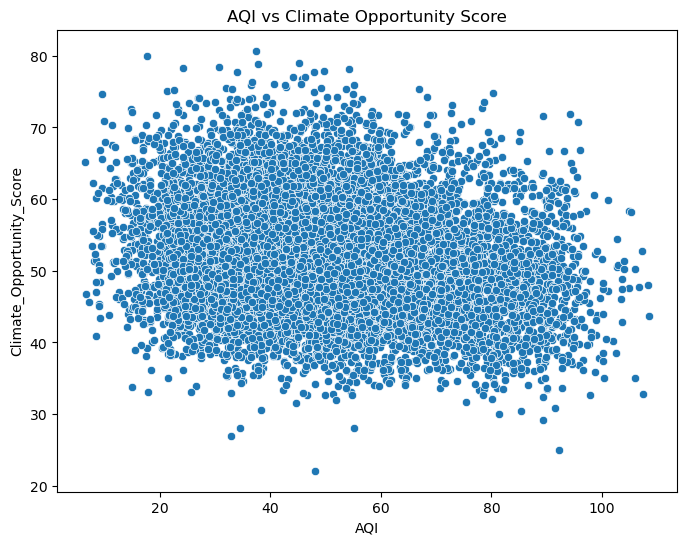

In [4148]:
plt.figure(figsize=(8,6))

sns.scatterplot(
    data=clean_df,
    x="AQI",
    y="Climate_Opportunity_Score"
)

plt.title("AQI vs Climate Opportunity Score")

plt.show()

Correlation matrix

In [4149]:
numeric_cols = [
    "Temperature_C",
    "Humidity_Percent",
    "AQI",
    "Energy_Demand_MW",
    "Energy_Price_INR_kWh",
    "Climate_Opportunity_Score"
]

corr = clean_df[numeric_cols].corr()

corr

,Temperature_C,Humidity_Percent,AQI,Energy_Demand_MW,Energy_Price_INR_kWh,Climate_Opportunity_Score
Temperature_C,1.000000,-0.599129,0.000646,-0.078077,-0.051107,0.027594
Humidity_Percent,-0.599129,1.000000,-0.071842,0.013637,-0.003904,0.034416
AQI,0.000646,-0.071842,1.000000,0.514825,0.504138,-0.189226
Energy_Demand_MW,-0.078077,0.013637,0.514825,1.000000,0.973067,-0.064755
Energy_Price_INR_kWh,-0.051107,-0.003904,0.504138,0.973067,1.000000,-0.126285
Climate_Opportunity_Score,0.027594,0.034416,-0.189226,-0.064755,-0.126285,1.000000


Heatmap

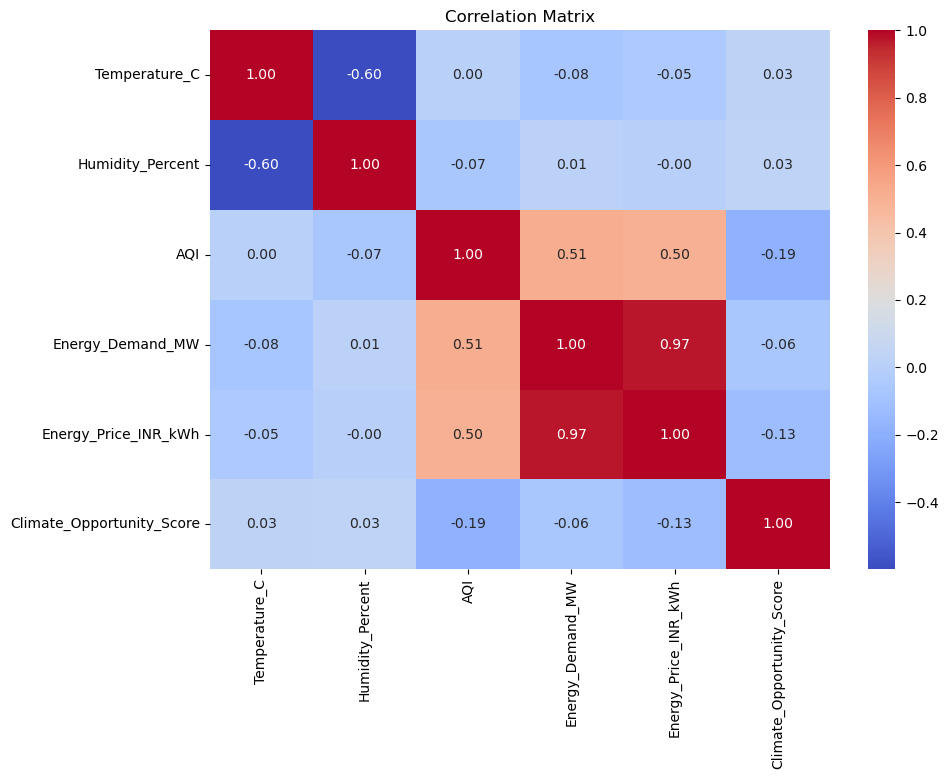

In [4150]:
plt.figure(figsize=(10,7))

sns.heatmap(
    corr,
    annot=True,
    cmap="coolwarm",
    fmt=".2f"
)

plt.title("Correlation Matrix")

plt.show()

In [4151]:
clean_df.head()

,Record_ID,Date,Time,City,Latitude,Longitude,Temperature_C,Feels_Like_C,Humidity_Percent,Dew_Point_C,...,Energy_Price_INR_kWh,Heat_Index_C,Pollution_Level,Climate_Opportunity_Score,Year,Month,Month_Name,Day,Day_of_Week,Hour
0,1,2025-01-01,00:00,Chennai,13.0827,80.2707,25.28,26.93,81.7,21.63,...,7.25,26.93,Good,47.7,2025,1,January,1,Wednesday,0
1,2,2025-01-01,01:00,Ahmedabad,23.0225,72.5714,25.98,27.61,89.6,23.91,...,6.69,27.61,Moderate,35.6,2025,1,January,1,Wednesday,1
2,3,2025-01-01,02:00,Delhi,28.6139,77.2090,20.18,20.56,70.9,14.37,...,11.32,20.56,Moderate,44.7,2025,1,January,1,Wednesday,2
3,4,2025-01-01,03:00,Mumbai,19.0760,72.8777,19.95,21.50,88.9,17.74,...,8.68,21.50,Moderate,39.0,2025,1,January,1,Wednesday,3
4,5,2025-01-01,04:00,Mumbai,19.0760,72.8777,20.91,23.27,89.3,18.78,...,9.11,23.27,Moderate,50.2,2025,1,January,1,Wednesday,4


In [4152]:
clean_df.drop("Year",axis=1,inplace=True)
clean_df.drop("Month",axis=1,inplace=True)
clean_df.drop("Month_Name",axis=1,inplace=True)
clean_df.drop("Day",axis=1,inplace=True)
clean_df.drop("Day_of_Week",axis=1,inplace=True)
clean_df.drop("Hour",axis=1,inplace=True)

In [4153]:
clean_df.head()

,Record_ID,Date,Time,City,Latitude,Longitude,Temperature_C,Feels_Like_C,Humidity_Percent,Dew_Point_C,...,NO2_ugm3,CO_mg_m3,O3_ugm3,AQI,Population_Millions,Energy_Demand_MW,Energy_Price_INR_kWh,Heat_Index_C,Pollution_Level,Climate_Opportunity_Score
0,1,2025-01-01,00:00,Chennai,13.0827,80.2707,25.28,26.93,81.7,21.63,...,43.99,0.452,26.04,43.7,11.0,409.0,7.25,26.93,Good,47.7
1,2,2025-01-01,01:00,Ahmedabad,23.0225,72.5714,25.98,27.61,89.6,23.91,...,47.12,0.787,25.83,60.9,8.0,333.2,6.69,27.61,Moderate,35.6
2,3,2025-01-01,02:00,Delhi,28.6139,77.2090,20.18,20.56,70.9,14.37,...,30.88,0.532,27.26,60.9,33.0,1272.5,11.32,20.56,Moderate,44.7
3,4,2025-01-01,03:00,Mumbai,19.0760,72.8777,19.95,21.50,88.9,17.74,...,46.07,0.774,36.93,54.4,21.0,778.4,8.68,21.50,Moderate,39.0
4,5,2025-01-01,04:00,Mumbai,19.0760,72.8777,20.91,23.27,89.3,18.78,...,34.95,0.900,27.26,52.0,21.0,793.9,9.11,23.27,Moderate,50.2


In [4154]:
clean_df.columns.tolist()

['Record_ID',
 'Date',
 'Time',
 'City',
 'Latitude',
 'Longitude',
 'Temperature_C',
 'Feels_Like_C',
 'Humidity_Percent',
 'Dew_Point_C',
 'Pressure_hPa',
 'Rainfall_mm',
 'Wind_Speed_kmh',
 'Cloud_Cover_Percent',
 'Solar_Radiation_Wm2',
 'PM2_5_ugm3',
 'PM10_ugm3',
 'NO2_ugm3',
 'CO_mg_m3',
 'O3_ugm3',
 'AQI',
 'Population_Millions',
 'Energy_Demand_MW',
 'Energy_Price_INR_kWh',
 'Heat_Index_C',
 'Pollution_Level',
 'Climate_Opportunity_Score']

In [4155]:
clean_df["Timestamp"] = pd.to_datetime(
    clean_df["Date"].astype(str) + " " + clean_df["Time"].astype(str),
    errors="coerce"
)

In [4156]:
clean_df[["Date", "Time", "Timestamp"]].head()

,Date,Time,Timestamp
0,2025-01-01,00:00,2025-01-01 00:00:00
1,2025-01-01,01:00,2025-01-01 01:00:00
2,2025-01-01,02:00,2025-01-01 02:00:00
3,2025-01-01,03:00,2025-01-01 03:00:00
4,2025-01-01,04:00,2025-01-01 04:00:00


In [4157]:
clean_df["Timestamp"].isna().sum()

np.int64(0)

In [4158]:
clean_df["Day"] = clean_df["Timestamp"].dt.day

clean_df["Day_of_Week"] = clean_df["Timestamp"].dt.day_name()

clean_df["Month"] = clean_df["Timestamp"].dt.month

clean_df["Year"] = clean_df["Timestamp"].dt.year

In [4159]:
clean_df

,Record_ID,Date,Time,City,Latitude,Longitude,Temperature_C,Feels_Like_C,Humidity_Percent,Dew_Point_C,...,Energy_Demand_MW,Energy_Price_INR_kWh,Heat_Index_C,Pollution_Level,Climate_Opportunity_Score,Timestamp,Day,Day_of_Week,Month,Year
0,1,2025-01-01,00:00,Chennai,13.0827,80.2707,25.28,26.93,81.7,21.63,...,409.0,7.25,26.93,Good,47.7,2025-01-01 00:00:00,1,Wednesday,1,2025
1,2,2025-01-01,01:00,Ahmedabad,23.0225,72.5714,25.98,27.61,89.6,23.91,...,333.2,6.69,27.61,Moderate,35.6,2025-01-01 01:00:00,1,Wednesday,1,2025
2,3,2025-01-01,02:00,Delhi,28.6139,77.2090,20.18,20.56,70.9,14.37,...,1272.5,11.32,20.56,Moderate,44.7,2025-01-01 02:00:00,1,Wednesday,1,2025
3,4,2025-01-01,03:00,Mumbai,19.0760,72.8777,19.95,21.50,88.9,17.74,...,778.4,8.68,21.50,Moderate,39.0,2025-01-01 03:00:00,1,Wednesday,1,2025
4,5,2025-01-01,04:00,Mumbai,19.0760,72.8777,20.91,23.27,89.3,18.78,...,793.9,9.11,23.27,Moderate,50.2,2025-01-01 04:00:00,1,Wednesday,1,2025
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
11995,11996,2026-05-15,19:00,Kochi,9.9312,76.2673,32.87,34.07,62.6,25.39,...,153.0,6.88,34.07,Moderate,60.3,2026-05-15 19:00:00,15,Friday,5,2026
11996,11997,2026-05-15,20:00,Chennai,13.0827,80.2707,35.71,35.49,55.5,26.82,...,491.6,8.37,35.49,Good,48.8,2026-05-15 20:00:00,15,Friday,5,2026
11997,11998,2026-05-15,21:00,Kochi,9.9312,76.2673,35.17,34.15,58.3,26.84,...,161.7,6.79,34.15,Good,54.4,2026-05-15 21:00:00,15,Friday,5,2026
11998,11999,2026-05-15,22:00,Hyderabad,17.3850,78.4867,31.41,31.61,60.8,23.57,...,429.2,8.11,31.61,Good,53.1,2026-05-15 22:00:00,15,Friday,5,2026


Time-series analysis

Daily average temperature

In [4160]:
daily_temperature = (
    clean_df
    .groupby(clean_df["Timestamp"].dt.date)["Temperature_C"]
    .mean()
)

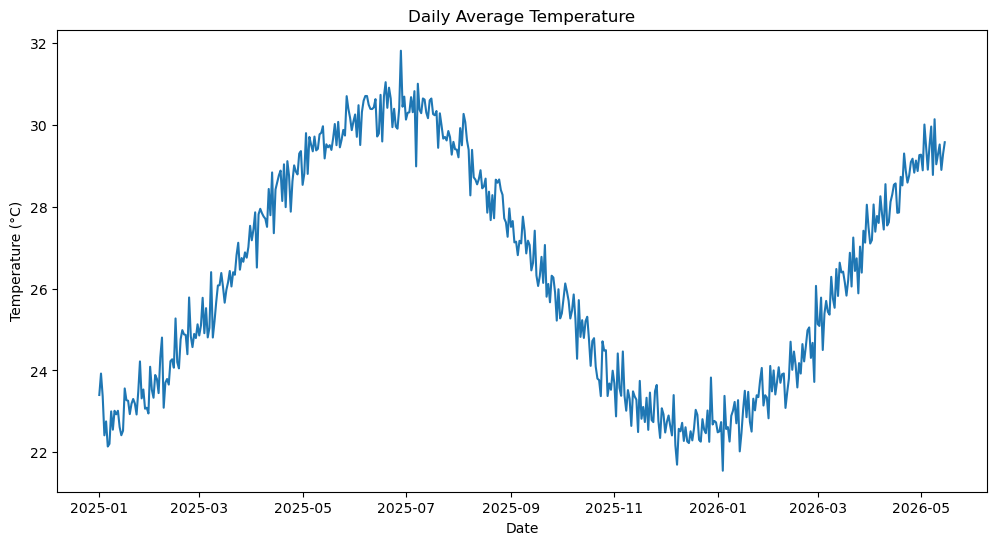

In [4161]:
daily_temperature.plot(figsize=(12,6))

plt.title("Daily Average Temperature")
plt.xlabel("Date")
plt.ylabel("Temperature (°C)")

plt.show()

Energy demand

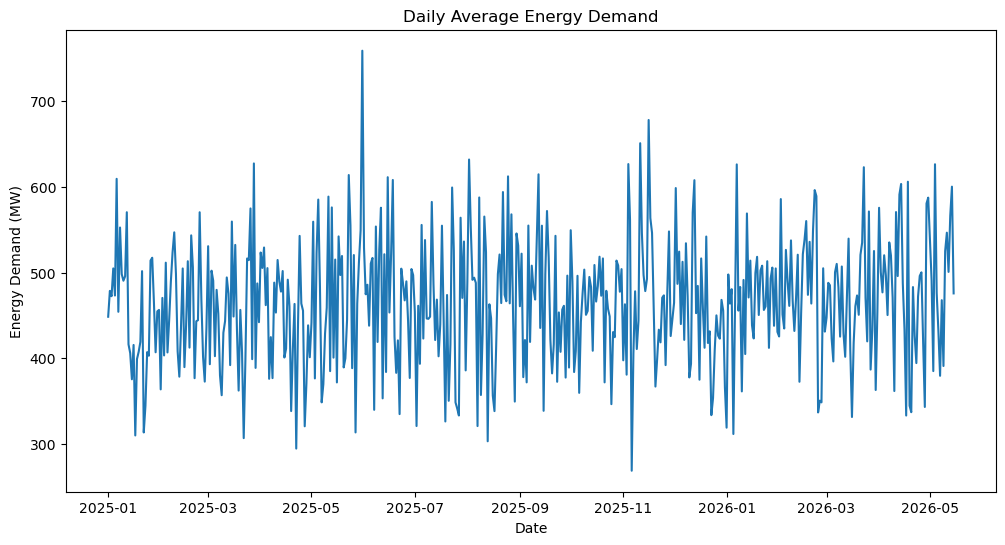

In [4162]:
daily_energy = (
    clean_df
    .groupby(clean_df["Timestamp"].dt.date)["Energy_Demand_MW"]
    .mean()
)

daily_energy.plot(figsize=(12,6))

plt.title("Daily Average Energy Demand")
plt.xlabel("Date")
plt.ylabel("Energy Demand (MW)")

plt.show()

Identify high-risk climate conditions

In [4163]:
temperature_threshold = clean_df["Temperature_C"].quantile(0.90)
aqi_threshold = clean_df["AQI"].quantile(0.90)

In [4164]:
clean_df["Climate_Risk_Flag"] = np.where(
    (clean_df["Temperature_C"] >= temperature_threshold) |
    (clean_df["AQI"] >= aqi_threshold),
    "High",
    "Normal"
)

In [4165]:
clean_df["Climate_Risk_Flag"].value_counts()

Climate_Risk_Flag
Normal    9661
High      2339
Name: count, dtype: int64

In [4166]:
clean_df["Opportunity_Category"] = pd.qcut(
    clean_df["Climate_Opportunity_Score"],
    q=3,
    labels=["Low", "Medium", "High"]
)

In [4167]:
clean_df["Opportunity_Category"].value_counts()

Opportunity_Category
Low       4028
Medium    3992
High      3980
Name: count, dtype: int64